In [1]:
#setup environment
from IPython.display import Image, display

!git clone https://github.com/giankev/KV_Cache-Compression-Benchmark.git
%cd KV_Cache-Compression-Benchmark
!pip install -e .

Cloning into 'KV_Cache-Compression-Benchmark'...
remote: Enumerating objects: 319, done.
remote: Counting objects: 100% (319/319), done.
remote: Compressing objects: 100% (211/211), done.
remote: Total 319 (delta 191), reused 216 (delta 88), pack-reused 0 (from 0)
Receiving objects: 100% (319/319), 283.93 KiB | 3.55 MiB/s, done.
Resolving deltas: 100% (191/191), done.
/kaggle/working/KV_Cache-Compression-Benchmark
Obtaining file:///kaggle/working/KV_Cache-Compression-Benchmark
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 13.2 MB/s e

tokenizer_config.json: 7.30kB [00:00, 36.1MB/s]
vocab.json: 2.78MB [00:00, 45.8MB/s]
merges.txt: 1.67MB [00:00, 122MB/s]
tokenizer.json: 7.03MB [00:00, 165MB/s]
config.json: 100%|█████████████████████████████| 661/661 [00:00<00:00, 7.64MB/s]
model.safetensors.index.json: 35.6kB [00:00, 106MB/s]
Fetching 2 files:   0%|                                   | 0/2 [00:00<?, ?it/s]
model-00001-of-00002.safetensors:   0%|             | 0.00/3.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|             | 0.00/2.20G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|             | 0.00/2.20G [00:00<?, ?B/s]
model-00001-of-00002.safetensors:   0%|             | 0.00/3.97G [00:00<?, ?B/s]
model-00001-of-00002.safetensors:   0%|             | 0.00/3.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|             | 0.00/2.20G [00:00<?, ?B/s]
model-00001-of-00002.safetensors:   0%|             | 0.00/3.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|             

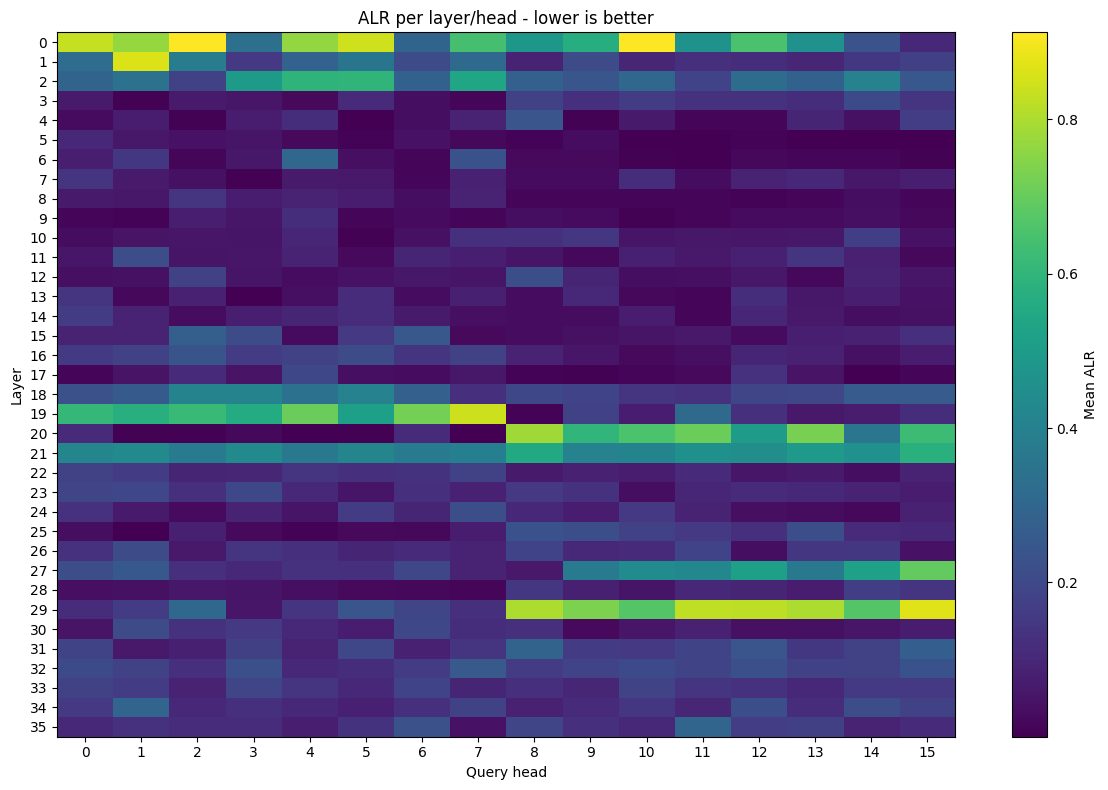

In [2]:
#alr heatmap correlation
!python scripts/show_alr_heatmap.py
display(Image("results/alr_heatmap.png"))

# BENCHMARK L2-NORM

In [4]:
!python scripts/run_l2_passkey.py \
  --model-name Qwen/Qwen2.5-3B-Instruct \
  --context-lengths 16384 \
  --seeds 0 1 2 \
  --keep-ratio 0.10 \
  --skip-layers 0 1 \
  --chunk-size 512 \
  --output-prefix l2_passkey_3b_16k_keep10

Loading Qwen/Qwen2.5-3B-Instruct
tokenizer_config.json: 7.30kB [00:00, 3.22MB/s]
vocab.json: 2.78MB [00:00, 46.7MB/s]
merges.txt: 1.67MB [00:00, 129MB/s]
tokenizer.json: 7.03MB [00:00, 174MB/s]
config.json: 100%|█████████████████████████████| 661/661 [00:00<00:00, 4.35MB/s]
model.safetensors.index.json: 35.6kB [00:00, 111MB/s]
Fetching 2 files:   0%|                                   | 0/2 [00:00<?, ?it/s]
model-00002-of-00002.safetensors:   0%|             | 0.00/2.20G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|             | 0.00/3.97G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|             | 0.00/3.97G [00:00<?, ?B/s]
model-00002-of-00002.safetensors:   0%|             | 0.00/2.20G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|             | 0.00/3.97G [00:00<?, ?B/s]
model-00002-of-00002.safetensors:   0%|             | 0.00/2.20G [00:00<?, ?B/s]
model-00002-of-00002.safetensors:   0%|             | 0.00/2.20G [00:00<?, ?B/s]

model-00001-of-0000

# BENCHMARK SNAPKV

In [5]:
!python scripts/run_snapkv_passkey.py \
  --model-name Qwen/Qwen2.5-3B-Instruct \
  --context-lengths 16384 \
  --seeds 0 1 2 \
  --target-cache-tokens 1024 \
  --observation-window-size 32 \
  --pooling-kernel-size 5 \
  --pooling-mode max \
  --chunk-size 512 \
  --output-prefix snapkv_passkey_3b_16k

Loading Qwen/Qwen2.5-3B-Instruct
Loading checkpoint shards: 100%|██████████████████| 2/2 [00:02<00:00,  1.12s/it]
Run metadata:
  script: run_snapkv_passkey.py
  torch_version: 2.10.0+cu128
  transformers_version: 4.57.6
  model_name: Qwen/Qwen2.5-3B-Instruct
  model_revision: aa8e72537993ba99e69dfaafa59ed015b17504d1
  requested_dtype: auto
  model_dtype: torch.bfloat16
  device: cuda:0
  device_map: {"lm_head": 0, "model.embed_tokens": 0, "model.layers.0": 0, "model.layers.1": 0, "model.layers.10": 0, "model.layers.11": 0, "model.layers.12": 0, "model.layers.13": 0, "model.layers.14": 0, "model.layers.15": 0, "model.layers.16": 1, "model.layers.17": 1, "model.layers.18": 1, "model.layers.19": 1, "model.layers.2": 0, "model.layers.20": 1, "model.layers.21": 1, "model.layers.22": 1, "model.layers.23": 1, "model.layers.24": 1, "model.layers.25": 1, "model.layers.26": 1, "model.layers.27": 1, "model.layers.28": 1, "model.layers.29": 1, "model.layers.3": 0, "model.layers.30": 1, "model.lay

# BENCHMARK KEYDIFF

In [5]:
!python scripts/run_keydiff_passkey.py \
  --model-name Qwen/Qwen2.5-3B-Instruct \
  --context-lengths 16384 \
  --seeds 0 1 2\
  --keep-ratio 0.10 \
  --chunk-size 512 \
  --output-prefix keydiff_passkey_sanity_4k

Loading Qwen/Qwen2.5-3B-Instruct
Loading checkpoint shards: 100%|██████████████████| 2/2 [00:02<00:00,  1.08s/it]
Run metadata:
  script: run_keydiff_passkey.py
  torch_version: 2.10.0+cu128
  transformers_version: 4.57.6
  model_name: Qwen/Qwen2.5-3B-Instruct
  model_revision: aa8e72537993ba99e69dfaafa59ed015b17504d1
  requested_dtype: auto
  model_dtype: torch.bfloat16
  device: cuda:0
  device_map: {"lm_head": 0, "model.embed_tokens": 0, "model.layers.0": 0, "model.layers.1": 0, "model.layers.10": 0, "model.layers.11": 0, "model.layers.12": 0, "model.layers.13": 0, "model.layers.14": 0, "model.layers.15": 0, "model.layers.16": 1, "model.layers.17": 1, "model.layers.18": 1, "model.layers.19": 1, "model.layers.2": 0, "model.layers.20": 1, "model.layers.21": 1, "model.layers.22": 1, "model.layers.23": 1, "model.layers.24": 1, "model.layers.25": 1, "model.layers.26": 1, "model.layers.27": 1, "model.layers.28": 1, "model.layers.29": 1, "model.layers.3": 0, "model.layers.30": 1, "model.la

# Language Modelling Task

In [2]:
!python scripts/run_online_lm.py \
  --max-cache-tokens 2000

Loading Qwen/Qwen2.5-3B-Instruct
tokenizer_config.json: 7.30kB [00:00, 2.71MB/s]
vocab.json: 2.78MB [00:00, 46.8MB/s]
merges.txt: 1.67MB [00:00, 106MB/s]
tokenizer.json: 7.03MB [00:00, 159MB/s]
config.json: 100%|█████████████████████████████| 661/661 [00:00<00:00, 6.12MB/s]
model.safetensors.index.json: 35.6kB [00:00, 113MB/s]
Fetching 2 files:   0%|                                   | 0/2 [00:00<?, ?it/s]
model-00002-of-00002.safetensors:   0%|             | 0.00/2.20G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|             | 0.00/3.97G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|             | 0.00/3.97G [00:00<?, ?B/s]
model-00002-of-00002.safetensors:   0%|             | 0.00/2.20G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|             | 0.00/3.97G [00:00<?, ?B/s]
model-00002-of-00002.safetensors:   0%|             | 0.00/2.20G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|             | 0.00/3.97G [00:00<?, ?B/s]
model-00002-of-0000

In [2]:
!python scripts/run_online_lm.py \
  --max-cache-tokens 1000

Loading Qwen/Qwen2.5-3B-Instruct
tokenizer_config.json: 7.30kB [00:00, 2.34MB/s]
vocab.json: 2.78MB [00:00, 42.9MB/s]
merges.txt: 1.67MB [00:00, 113MB/s]
tokenizer.json: 7.03MB [00:00, 152MB/s]
config.json: 100%|█████████████████████████████| 661/661 [00:00<00:00, 3.17MB/s]
model.safetensors.index.json: 35.6kB [00:00, 82.5MB/s]
Fetching 2 files:   0%|                                   | 0/2 [00:00<?, ?it/s]
model-00001-of-00002.safetensors:   0%|             | 0.00/3.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|             | 0.00/2.20G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|             | 0.00/2.20G [00:00<?, ?B/s]
model-00001-of-00002.safetensors:   0%|             | 0.00/3.97G [00:00<?, ?B/s]
model-00001-of-00002.safetensors:   0%|             | 0.00/3.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|             | 0.00/2.20G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|             | 0.00/2.20G [00:00<?, ?B/s]
model-00001-of-000

# PLOT

In [3]:
!python scripts/plot_online_lm.py \
  --input-csv results/online_lm_curve.csv \
  --output results/online_lm_log_ppl.png \
  --accuracy-output results/online_lm_accuracy.png

Saved results/online_lm_log_ppl.png
Saved results/online_lm_accuracy.png


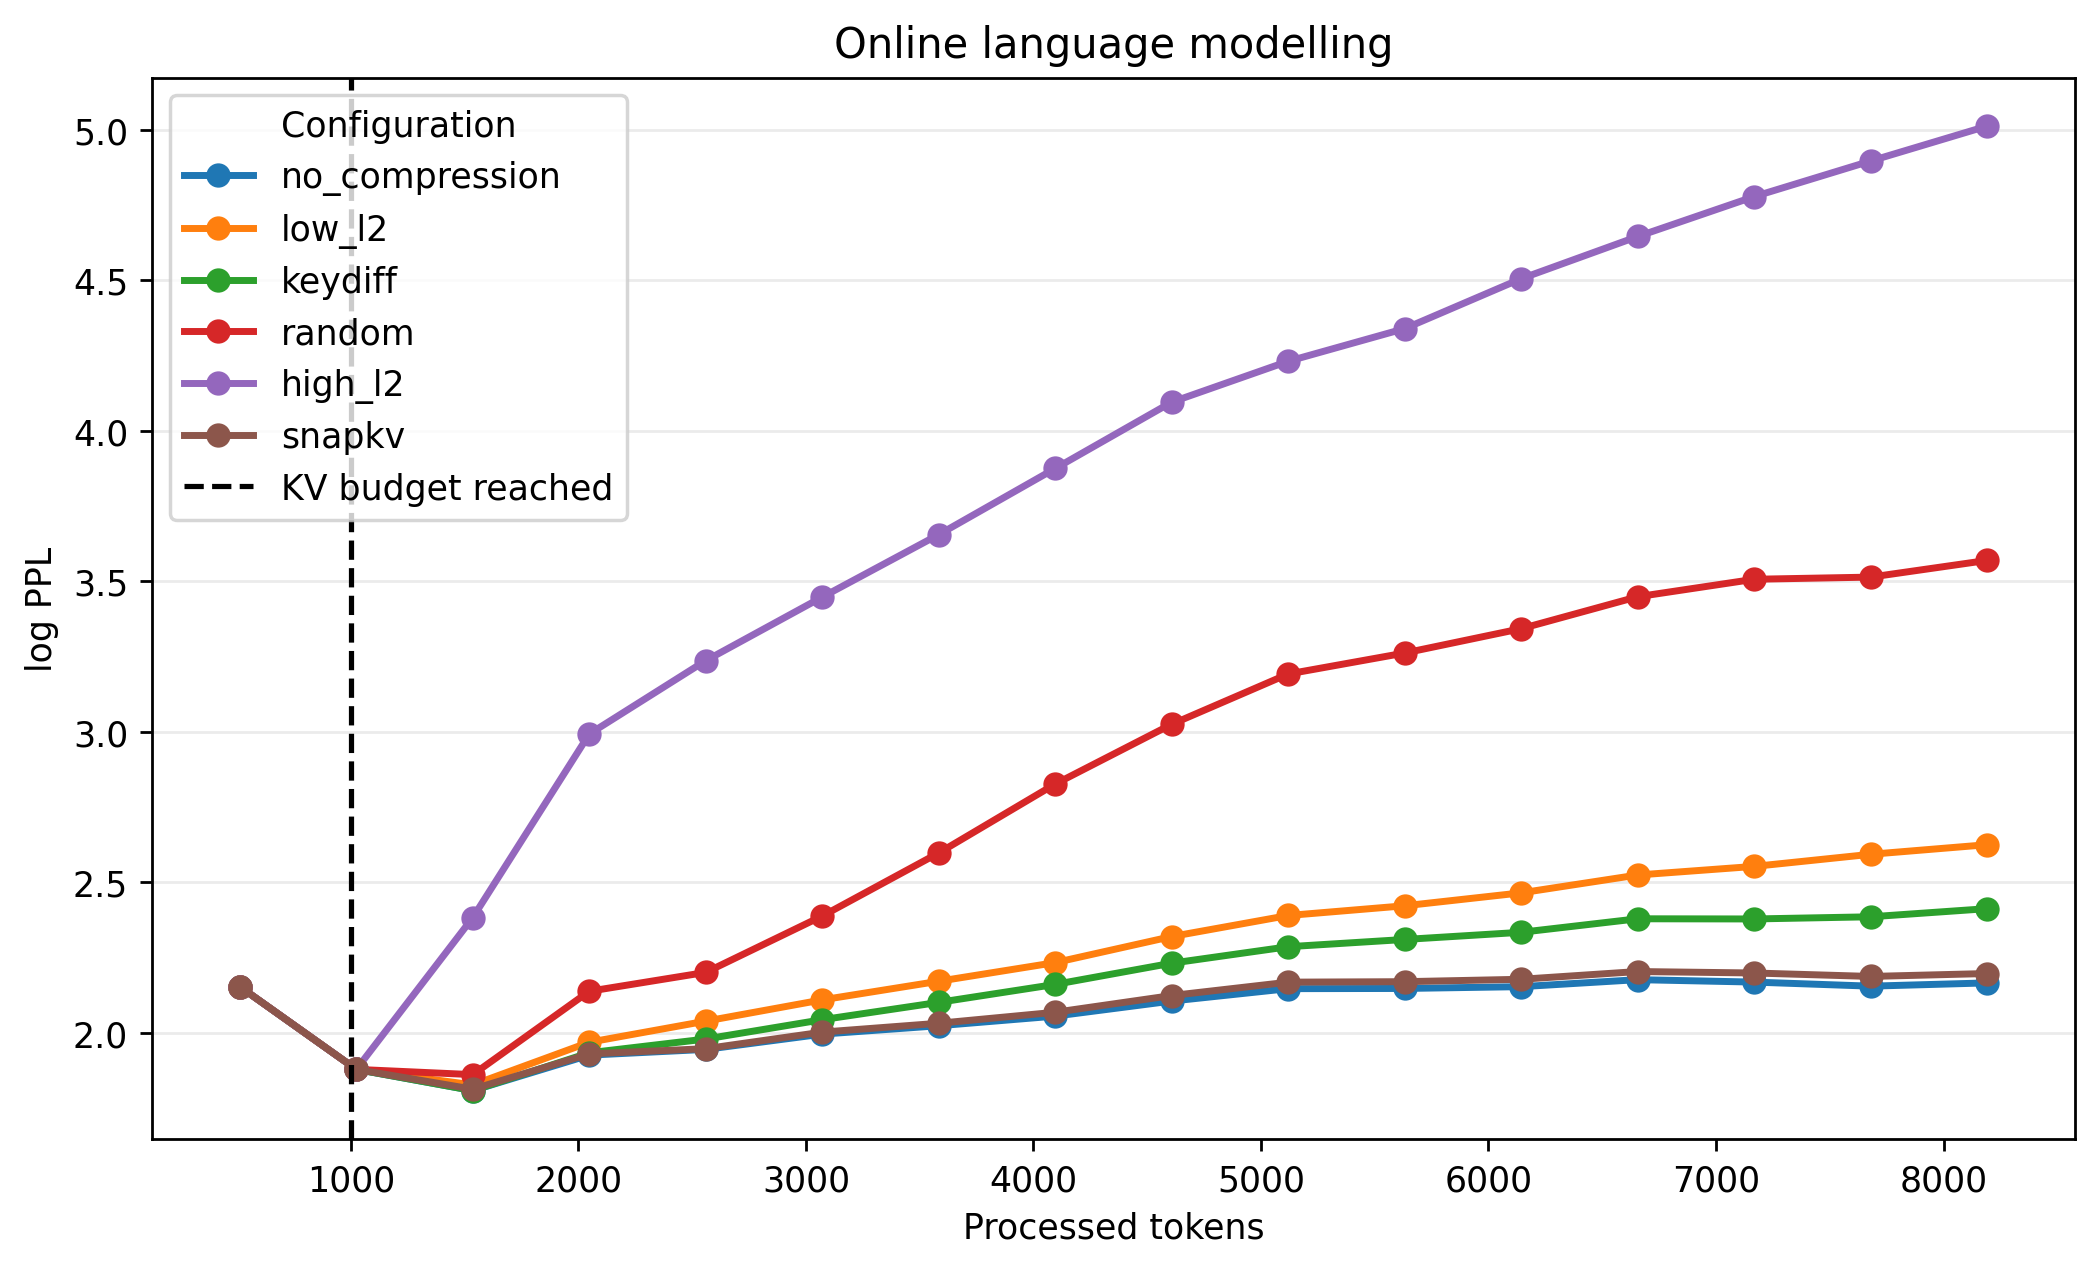

In [4]:
display(Image("results/online_lm_log_ppl.png"))

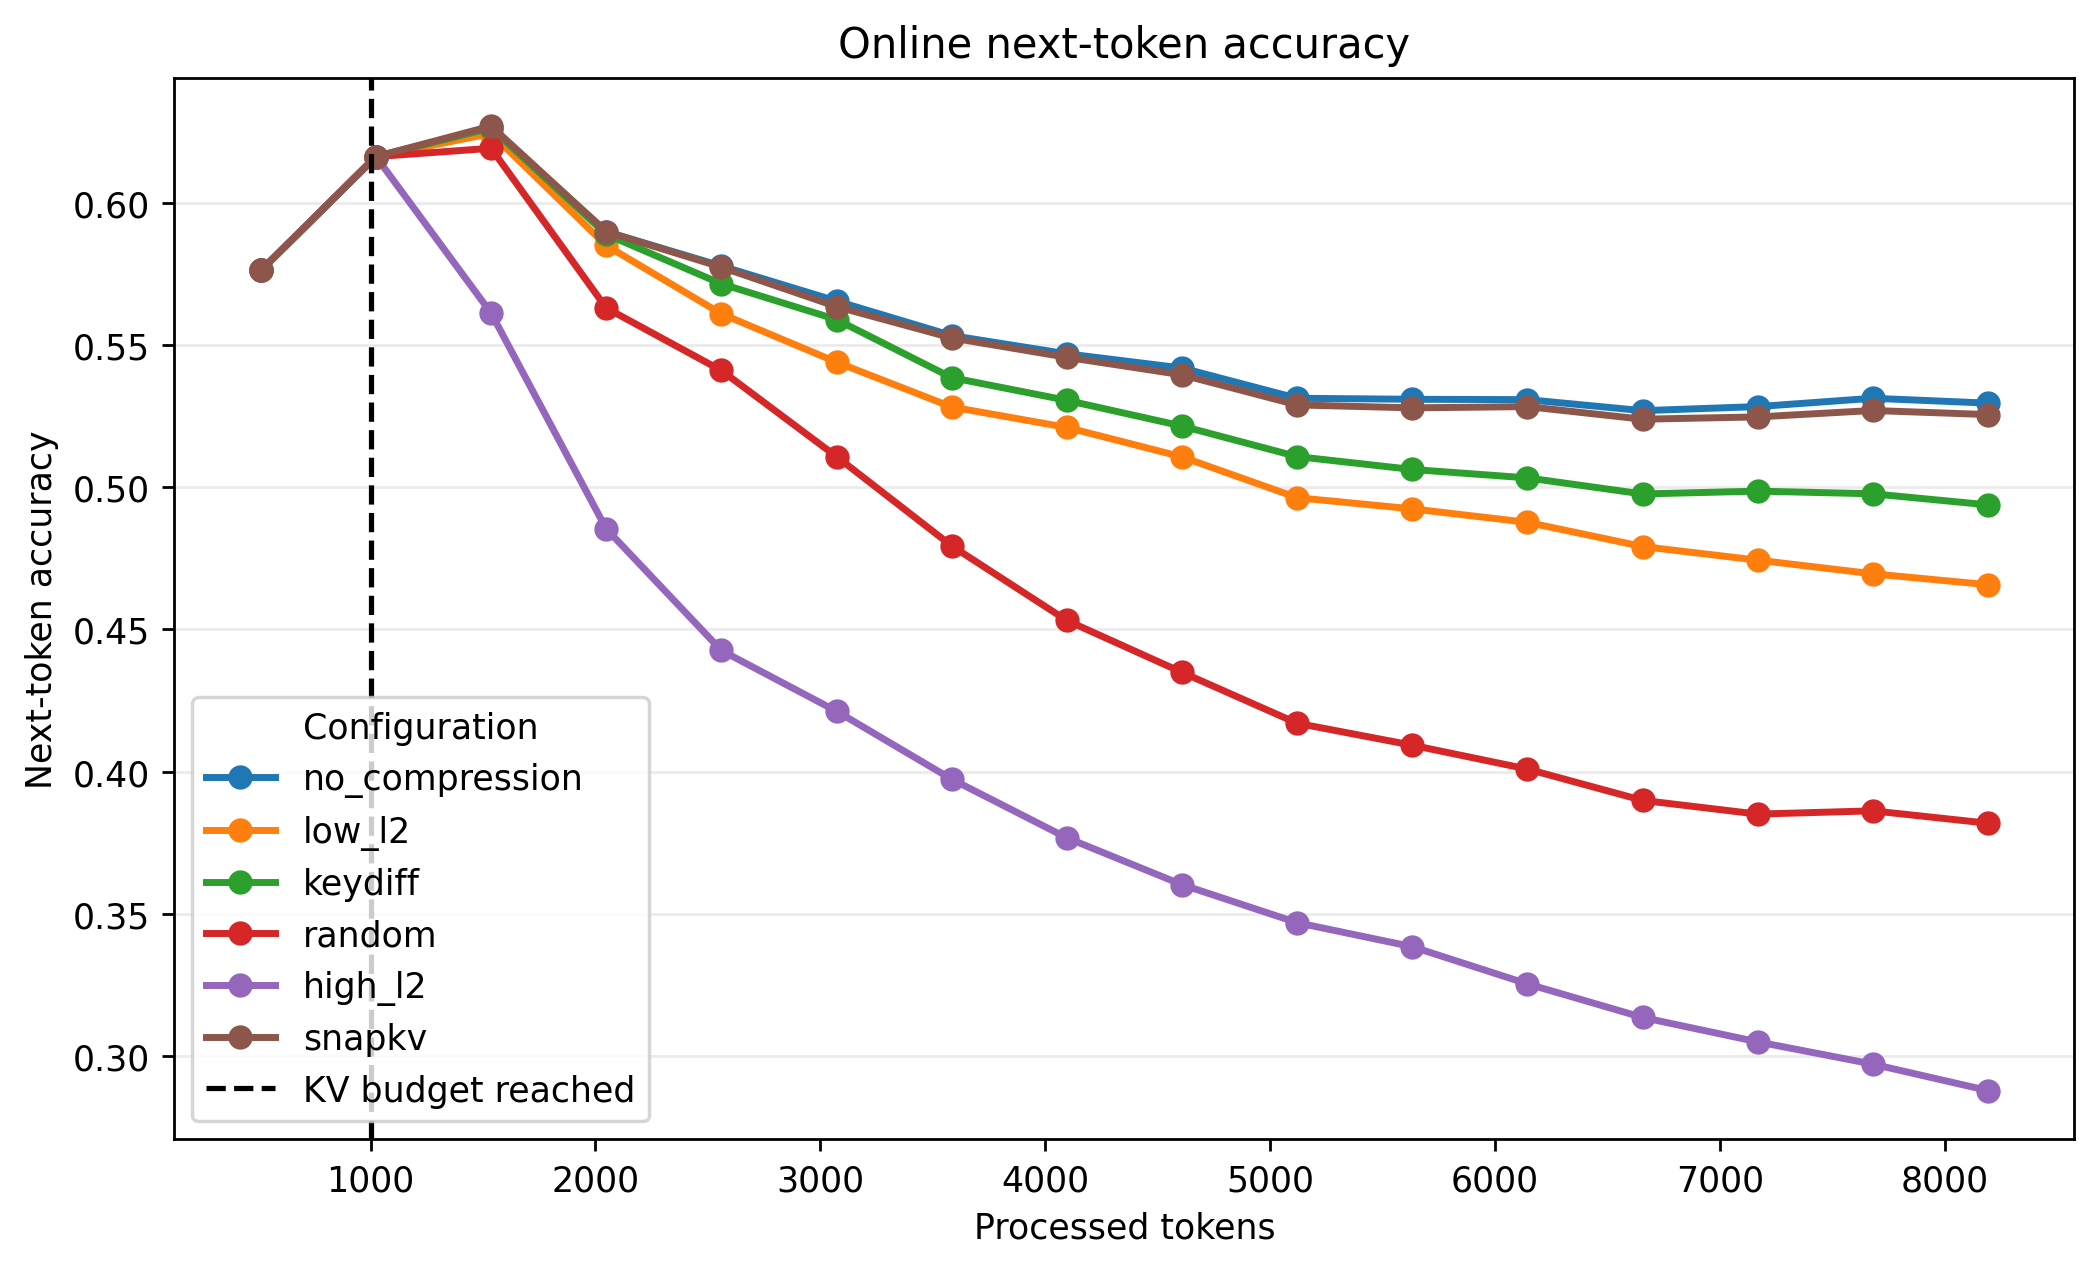

In [5]:
display(Image("results/online_lm_accuracy.png"))